### Visão Geral

O objetivo desse projeto foi aplicar conhecimentos sobre **Machine Learning tradicional** para explorar os dados disponibilizados pelo **State Of Data Brazil** no ano de 2024, utilizando-os para treinar um modelo de classificação que prediz a faixa salarial de um indivíduo. Ao decorrer dos **4 notebooks** será possível acompanhar desde a analise exploratória do dataset até a avaliação final do modelo.

### 1.1. Analise inicial dos dados



In [85]:
import matplotlib.pyplot as plt
from src.data_loading import load_data

#importando dados iniciais de raw data
df = load_data()

In [86]:
df.head()

,0.a_token,0.d_data/hora_envio,1.a_idade,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.d_pcd,1.e_experiencia_profissional_prejudicada,1.e.1_Não acredito que minha experiência profissional seja afetada,"1.e.2_Sim, devido a minha Cor/Raça/Etnia",...,"8.d.3_Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.",8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).,"8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.","8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.","8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.","8.d.8_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.","8.d.9_Criando e dando manutenção em ETLs, DAGs e automações de pipelines de dados.",8.d.10_Criando e gerenciando soluções de Feature Store e cultura de MLOps.,"8.d.11_Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)",8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
0,reb94rv0msth7q4nreb94riaq80iz3yi,16/10/2024 11:19:17,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1zc66g69jjt49y32l1zc66g8wqj79m4e,16/10/2024 20:45:31,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,uu99wmam4n5kc2uu99wmydf0rk7l58f7,17/10/2024 18:10:59,18,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3ynsw7z0hl5hhpbfvaeqk73ynsw7z04l,22/10/2024 18:03:00,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,v6bji2ct5xckpl1uouv6bjiotkrf3b4f,23/10/2024 01:33:23,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
df.shape

(5217, 403)

#### Analise do tamanho do dataset

O dataset possui **5217 instâncias** e **403 colunas**. Como o número de colunas é alto, a filtragem das features a serem utilizadas vai levar em consideração os principais fatores de impacto salarial na área de TI ( como serioridade, nível técnico e etc. ).

O primeiro passo será buscar a coluna target

### 1.2. Buscando Target

In [106]:
#verificando detalhadamente cada coluna para fazer uma filtragem inicial
df.columns

Index(['0.a_token', '0.d_data/hora_envio', '1.a_idade', '1.a.1_faixa_idade',
       '1.b_genero', '1.c_cor/raca/etnia', '1.d_pcd',
       '1.e_experiencia_profissional_prejudicada',
       '1.e.1_Não acredito que minha experiência profissional seja afetada',
       '1.e.2_Sim, devido a minha Cor/Raça/Etnia',
       ...
       '8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).',
       '8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.',
       '8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.',
       '8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.',
       '8.d.8_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.',
       '8.d.9_Criando e dando manutenção em ETLs, DAGs 

_OBS: como o objetivo é prever a faixa salarial do indivíduo, a coluna '2.h_faixa_salarial' se destaca inicialmente, mas exige uma analise mais detalhada_

In [89]:

df['2.h_faixa_salarial'].value_counts().sort_values()

2.h_faixa_salarial
Menos de R$ 1.000/mês                 33
Acima de R$ 40.001/mês               104
de R$ 1.001/mês a R$ 2.000/mês       155
de R$ 30.001/mês a R$ 40.000/mês     158
de R$ 25.001/mês a R$ 30.000/mês     159
de R$ 2.001/mês a R$ 3.000/mês       237
de R$ 20.001/mês a R$ 25.000/mês     246
de R$ 3.001/mês a R$ 4.000/mês       270
de R$ 16.001/mês a R$ 20.000/mês     456
de R$ 4.001/mês a R$ 6.000/mês       593
de R$ 6.001/mês a R$ 8.000/mês       656
de R$ 12.001/mês a R$ 16.000/mês     716
de R$ 8.001/mês a R$ 12.000/mês     1080
Name: count, dtype: int64

Foram identificadas **13 categorias distintas** para o target, entretanto é visível que há um desabalanceamento entre os dados, especialente em faixas extremas.

Ex: ***"Menos de R$ 1.000/mês" com 33 exemplos*** x de ***"R$ 8.001/mês a R$ 12.000/mês" com 1080 exemplos***

Isso significa que a segunda categoria tem aproximadamente 32 vezes mais exemplos que a primeira. Por conta disso, será feito um agrupamento de 13 categorias para apenas 6, visando reduzir o desbalanceamento entre categorias.

In [90]:
#Agrupando as 13 categorias em 6 maiores
novas_categorias = {
    'Menos de R$ 1.000/mês': 'até R$ 3.000/mês',
    'de R$ 1.001/mês a R$ 2.000/mês': 'até R$ 3.000/mês',
    'de R$ 2.001/mês a R$ 3.000/mês': 'até R$ 3.000/mês',
    'de R$ 3.001/mês a R$ 4.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 6.001/mês a R$ 8.000/mês': 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 8.001/mês a R$ 12.000/mês': 'de R$ 8.001/mês a R$ 12.000/mês',
    'de R$ 12.001/mês a R$ 16.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 20.001/mês a R$ 25.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 30.001/mês a R$ 40.000/mês': 'acima de R$ 20.000/mês',
    'Acima de R$ 40.001/mês': 'acima de R$ 20.000/mês'
}

df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)


C:\Users\Ian Guilherme Dev\AppData\Local\Temp\ipykernel_19912\3611629345.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)


In [91]:
#transformando em categorias ordinais
from pandas import CategoricalDtype
categorias = CategoricalDtype(categories=[
    'até R$ 3.000/mês',           
    'de 3.001/mês a R$ 6.000/mês',      
    'de R$ 6.001/mês a R$ 8.000/mês',      
    'de R$ 8.001/mês a R$ 12.000/mês',     
    'de R$ 12.001/mês a R$ 20.000/mês',    
    'acima de R$ 20.000/mês'      
], ordered=True)

df['categorias_target'] = df['categorias_target'].astype(categorias)



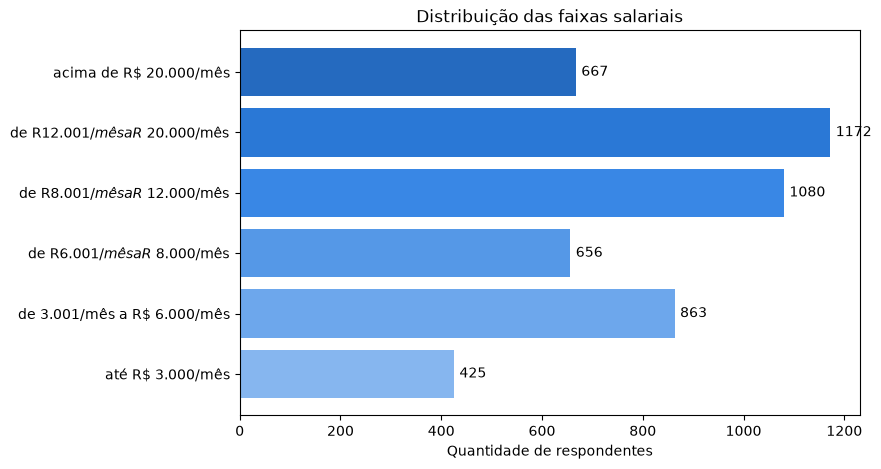

In [92]:
sequential_colors = ['#86b6ef', '#6da7ec', '#5598e7', '#3987e5', '#2a78d6', '#256abf']

counting = df['categorias_target'].value_counts().sort_index()

fig, axs = plt.subplots(figsize=(8, 5))
bars = axs.barh(counting.index, counting.values, color=sequential_colors)
axs.bar_label(bars, padding=4)
axs.set_xlabel('Quantidade de respondentes')
axs.set_title('Distribuição das faixas salariais')
plt.show()

#### NOTAS SOBRE O GRÁFICO:
- A redução de categorias **reduziu o desbalanceamento do dataset**
- As categorias extremas continuam sendo as de menor numero de exemplos (juntamente da categoria 'de R$ 6.001/mês a R$ 8.000/mês')

Agora é possível prosseguir para limpeza e seleção das features do modelo

### 1.3. Seleção das Features

_OBS: Removendo linhas com vive_em_brasil == False, pois quero centralizar essa pesquisa para pessoas que moram no território brasileiro._

In [93]:
df = df[df['1.g_vive_no_brasil']] 

Inicialmente foram removidos, da feature '2.a_situação_de_trabalho' as categorias:
- 'Vivo fora do Brasil e trabalho para empresa de fora do Brasil' -> (devido ao ***modelo ser específico para o território brasileiro***)
- 'Desempregado e não estou buscando recolocação' -> (devido a ***falta de faixa salarial***)

In [94]:
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

df = df[~df['2.a_situação_de_trabalho'].isin(remover)]
df = df[df['categorias_target'].notna()]

#### 1.3.1. Stack Features
- linguagem
- banco de dados
- cloud

<Axes: >

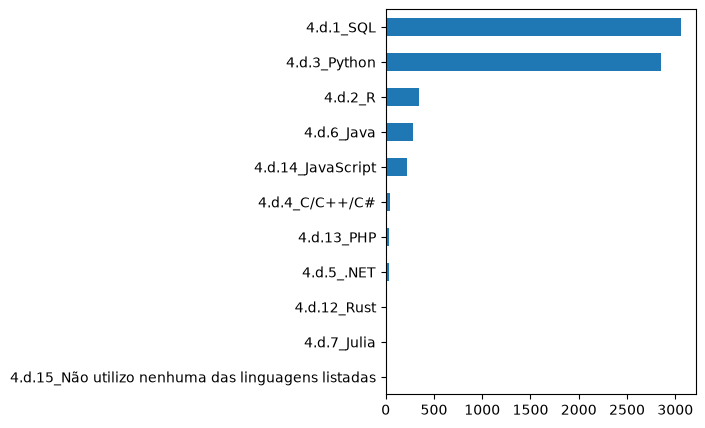

In [103]:
teste_filtro_por_linguagem = [ 
    '4.d.1_SQL',
    '4.d.2_R',
    '4.d.3_Python',
    '4.d.4_C/C++/C#',
    '4.d.5_.NET',
    '4.d.6_Java',
    '4.d.7_Julia',
    '4.d.12_Rust',
    '4.d.13_PHP',
    '4.d.14_JavaScript',
    '4.d.15_Não utilizo nenhuma das linguagens listadas'
]

df[teste_filtro_por_linguagem].dropna().sum().sort_values().plot(kind="barh", figsize=(4, 5))


- ***Linguagens Escolhidas***

O gráfico mostra que as linguagens de uso se *concentram basicamente em Python/SQL* (visto que a pesquisa deu enfoque à área de dados), então foram selecionadas apenas as 5 linguagens mais relevantes para essa pesquisa.

- '4.d.14_JavaScript',                                      
- '4.d.6_Java',
- '4.d.2_R',                                                
- '4.d.3_Python',                                          
- '4.d.1_SQL',

<Axes: >

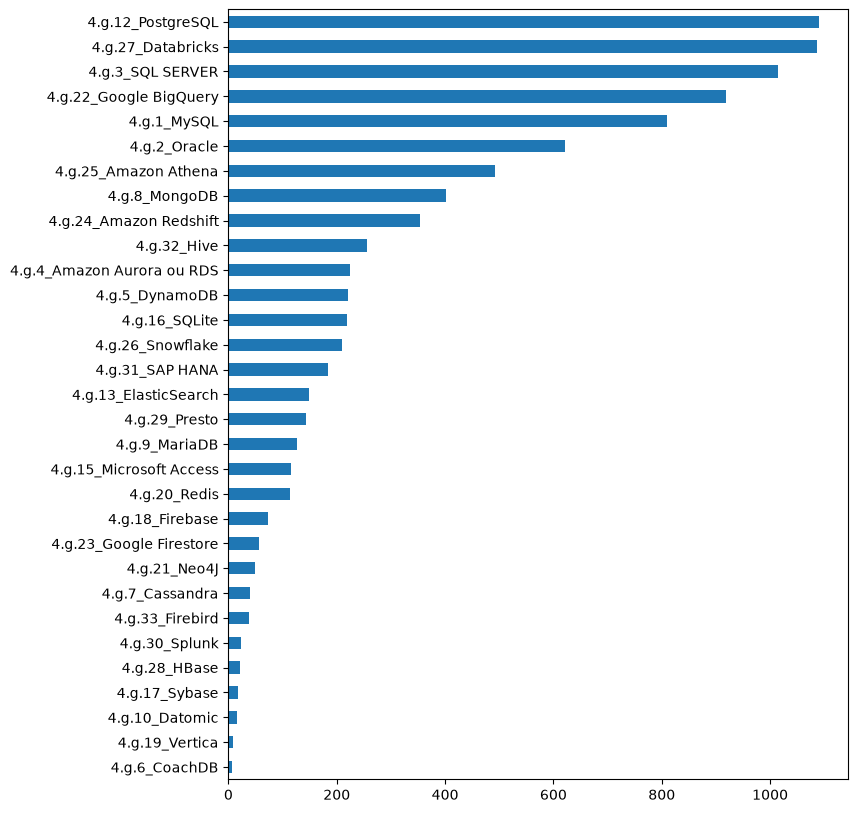

In [96]:
teste_filtro_por_db = [ 
'4.g.1_MySQL',
'4.g.2_Oracle',
'4.g.3_SQL SERVER',
'4.g.4_Amazon Aurora ou RDS',
'4.g.5_DynamoDB',
'4.g.6_CoachDB',
'4.g.7_Cassandra',
'4.g.8_MongoDB',
'4.g.9_MariaDB',
'4.g.10_Datomic',
'4.g.12_PostgreSQL',
'4.g.13_ElasticSearch',
'4.g.15_Microsoft Access',
'4.g.16_SQLite',
'4.g.17_Sybase',
'4.g.18_Firebase',
'4.g.19_Vertica',
'4.g.20_Redis',
'4.g.21_Neo4J',
'4.g.22_Google BigQuery',
'4.g.23_Google Firestore',
'4.g.24_Amazon Redshift',
'4.g.25_Amazon Athena',
'4.g.26_Snowflake',
'4.g.27_Databricks',
'4.g.28_HBase',
'4.g.29_Presto',
'4.g.30_Splunk',
'4.g.31_SAP HANA',
'4.g.32_Hive',
'4.g.33_Firebird',

]

df[teste_filtro_por_db].sum().sort_values(ascending=True).plot(kind="barh", figsize=(8, 10))


- ***Banco de Dados Escolhidos*** 

O gráfico mostra que 6 bancos concentram a maioria do uso, com queda acentuada depois de Oracle — o que motiva o corte em top-6.

- 4.g.2_Oracle                   
- 4.g.1_MySQL                    
- 4.g.22_Google BigQuery         
- 4.g.3_SQL SERVER              
- 4.g.27_Databricks             
- 4.g.12_PostgreSQL             

<Axes: >

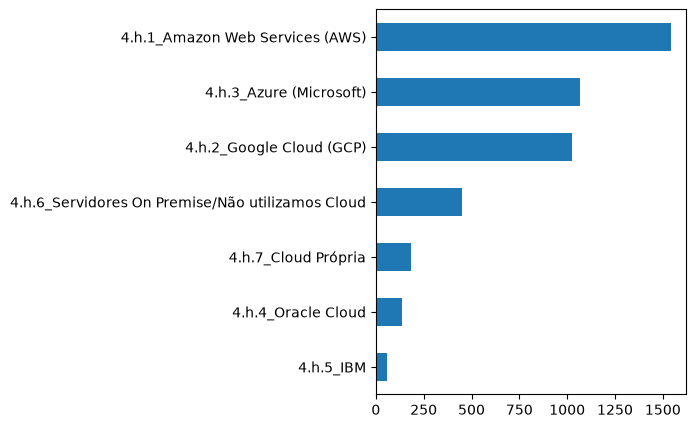

In [97]:
teste_filtro_por_cloud = [ 
'4.h.1_Amazon Web Services (AWS)',
'4.h.2_Google Cloud (GCP)',
'4.h.3_Azure (Microsoft)',
'4.h.4_Oracle Cloud',
'4.h.5_IBM',
'4.h.6_Servidores On Premise/Não utilizamos Cloud',
'4.h.7_Cloud Própria'
]

df[teste_filtro_por_cloud].sum().sort_values(ascending=True).plot(kind="barh", figsize=(4, 5))


- ***Clouds Escolhidos*** 

Apenas as 4 primeiras categorias concentram a parte majoritária dos clouds indentificados nessa pesquisa, motivando a seleção abaixo:

- '4.h.6_Servidores On Premise/Não utilizamos Cloud',
- '4.h.2_Google Cloud (GCP)',
- '4.h.3_Azure (Microsoft)',
- '4.h.1_Amazon Web Services (AWS)',

In [98]:
df['2.j_tempo_de_experiencia_em_ti'].value_counts().sort_index()

2.j_tempo_de_experiencia_em_ti
Mais de 10 anos                                                                                             379
Menos de 1 ano                                                                                              444
Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados    2572
de 1 a 2 anos                                                                                               533
de 3 a 4 anos                                                                                               377
de 5 a 6 anos                                                                                               213
de 7 a 10 anos                                                                                              204
Name: count, dtype: int64

### 1.4. Selecionando Features Finais

In [99]:
#selecionando as features
selecionado = [
    '1.a_idade',
    '1.i.1_uf_onde_mora',
    '1.l_nivel_de_ensino', 
    '1.m_área_de_formação',
    '2.a_situação_de_trabalho',
    '2.b_setor',
    '2.f_cargo_atual',
    '2.g_nivel',   
    '2.j_tempo_de_experiencia_em_ti',
    '4.d.14_JavaScript',                                      
    '4.d.6_Java',
    '4.d.2_R',                                                
    '4.d.3_Python',                                          
    '4.d.1_SQL',
    '4.g.2_Oracle',           
    '4.g.1_MySQL',           
    '4.g.22_Google BigQuery', 
    '4.g.3_SQL SERVER',       
    '4.g.27_Databricks',      
    '4.g.12_PostgreSQL',
    '4.h.6_Servidores On Premise/Não utilizamos Cloud',
    '4.h.2_Google Cloud (GCP)',
    '4.h.3_Azure (Microsoft)',
    '4.h.1_Amazon Web Services (AWS)',
    'categorias_target'
]

df_tratado = (df[selecionado]
              .rename(columns={
                '1.a_idade': 'idade', 
                '1.i.1_uf_onde_mora': 'uf_onde_mora',
                '1.l_nivel_de_ensino': 'nivel_de_ensino', 
                '1.m_área_de_formação': 'area_formacao',
                '2.a_situação_de_trabalho': 'situacao_trabalho',
                '2.b_setor': 'setor',
                '2.f_cargo_atual': 'cargo_atual',
                '2.g_nivel': 'nivel_senioridade',   
                '2.j_tempo_de_experiencia_em_ti': 'tempo_experiencia',
                '4.d.14_JavaScript': 'JS',                                      
                '4.d.6_Java': 'Java',
                '4.d.2_R': 'R',                                                
                '4.d.3_Python': 'Python',                                          
                '4.d.1_SQL': 'SQL',
                '4.g.2_Oracle': 'Oracle',           
                '4.g.1_MySQL': 'MySQL',           
                '4.g.22_Google BigQuery': 'Google_BigQuery', 
                '4.g.3_SQL SERVER': 'SQL_Server',       
                '4.g.27_Databricks': 'Databricks',      
                '4.g.12_PostgreSQL': 'PostgreSQL',
                '4.h.6_Servidores On Premise/Não utilizamos Cloud': 'nao_utilizamos_cloud',
                '4.h.2_Google Cloud (GCP)': 'Google_cloud',
                '4.h.3_Azure (Microsoft)': 'Azure',
                '4.h.1_Amazon Web Services (AWS)': 'AWS'
                   
})) 

df_tratado

,idade,uf_onde_mora,nivel_de_ensino,area_formacao,situacao_trabalho,setor,cargo_atual,nivel_senioridade,tempo_experiencia,JS,...,MySQL,Google_BigQuery,SQL_Server,Databricks,PostgreSQL,nao_utilizamos_cloud,Google_cloud,Azure,AWS,categorias_target
0,18,RS,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Marketing,Analista de Dados/Data Analyst,Júnior,de 1 a 2 anos,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,até R$ 3.000/mês
1,18,SC,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Finanças ou Bancos,Analista de BI/BI Analyst,Júnior,Menos de 1 ano,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,até R$ 3.000/mês
2,18,SP,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Indústria,Outra Opção,Júnior,Não tive experiência na área de TI/Engenharia ...,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,até R$ 3.000/mês
3,18,SP,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,Analista de Dados/Data Analyst,Júnior,Não tive experiência na área de TI/Engenharia ...,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,até R$ 3.000/mês
4,18,SP,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,Menos de 1 ano,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,até R$ 3.000/mês
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5210,64,RJ,Pós-graduação,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Setor de Energia,Engenheiro de Dados/Data Engineer/Data Architect,Sênior,de 7 a 10 anos,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,acima de R$ 20.000/mês
5211,66,MG,Pós-graduação,Economia/ Administração / Contabilidade / Fina...,Empreendedor ou Empregado (CNPJ),Área da Saúde,NaN,NaN,de 1 a 2 anos,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,de R$ 12.001/mês a R$ 20.000/mês
5212,66,RS,Graduação/Bacharelado,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Área de Consultoria,NaN,NaN,Mais de 10 anos,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acima de R$ 20.000/mês
5213,66,DF,Mestrado,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Tecnologia/Fábrica de Software,Cientista de Dados/Data Scientist,Sênior,Mais de 10 anos,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,de R$ 12.001/mês a R$ 20.000/mês


In [100]:
df_tratado.to_csv('../data/processed/prepared_dataset.csv')